In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/processed/cleaned_merged.csv")
df.head()

,subject_id,screen_normal_day_1to6,screen_weekday_1to6,screen_weekend_1to6,sqi_fall_asleep_1to6,sqi_repeated_awake_1to6,sqi_disturbed_1to6,sqi_early_awake_1to6,bdi_item_01,bdi_item_02,...,bdi_item_21,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,2.0,3.0,5.0,1.0,3.0,2.0,3.0,0.0,1.0,...,0.0,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6.0,0.0
1,2,3.0,3.0,4.0,4.0,2.0,3.0,1.0,1.0,0.0,...,0.0,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7.0,0.0
2,3,3.0,3.0,4.0,3.0,1.0,3.0,1.0,1.0,1.0,...,1.0,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27.0,1.0
3,4,4.0,4.0,5.0,2.0,1.0,2.0,1.0,0.0,1.0,...,0.0,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22.0,1.0
4,5,3.0,1.0,1.0,2.0,2.0,4.0,2.0,0.0,0.0,...,0.0,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3.0,0.0


---
## step 2. defining target and features

In [2]:
target = "bdi_total"

screen_time_cols = [
    "screen_normal_day_1to6", "screen_weekday_1to6", "screen_weekend_1to6",
    "screen_time_index", "est_leisure_screen_hours"
]
sleep_quality_cols = [
    "sqi_fall_asleep_1to6", "sqi_repeated_awake_1to6",
    "sqi_disturbed_1to6", "sqi_early_awake_1to6",
    "sleep_quality_index", "avg_sleep_hours",
    "midsleep_weekend_hours", "social_jetlag_hours"
]
feature_cols = screen_time_cols + sleep_quality_cols

X = df[feature_cols]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4810, 13)
y shape: (4810,)


---
## **summary of features chosen**

`bdi_total` is the target. All `bdi_item_*` columns and `depressed` are excluded from X since both are mathematically derived from `bdi_total`. including them would leak the answer into the model.

---
**step 3. Train/test split**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 3848
Test observations: 962


---
## **step 4. linear regression model**

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.Series(model.coef_, index=feature_cols)
print("Intercept:", model.intercept_)
print(coefficients.sort_values())

Intercept: 6.781858155410693
screen_weekday_1to6        -239.842223
screen_weekend_1to6        -239.781321
screen_normal_day_1to6     -239.328356
avg_sleep_hours              -0.768310
midsleep_weekend_hours       -0.409344
sqi_disturbed_1to6           -0.295763
est_leisure_screen_hours      0.065370
sqi_repeated_awake_1to6       0.382013
sleep_quality_index           0.564081
social_jetlag_hours           0.565837
sqi_early_awake_1to6          0.985615
sqi_fall_asleep_1to6          1.184458
screen_time_index           719.463453
dtype: float64


---
## **explanation**
The coefficients reveal a serious problem: screen_time_index has a coefficient of about +719, while screen_normal_day_1to6, screen_weekday_1to6, and screen_weekend_1to6 each sit around -239; three nearly identical, large negative values. This pattern is a classic sign of multicollinearity: these four columns are almost certainly measuring the same underlying thing (screen_time_index is likely an average or composite of the other three), so the model can't tell which one is actually driving the relationship with bdi_total. Instead, it distributes a large positive effect onto one column and cancels it out with large negative effects on the correlated ones — the coefficients become unstable and effectively meaningless as individual indicators, even though the model's overall predictions may still be reasonable.

In [7]:
X[["screen_normal_day_1to6", "screen_weekday_1to6",
   "screen_weekend_1to6", "screen_time_index"]].corr()

,screen_normal_day_1to6,screen_weekday_1to6,screen_weekend_1to6,screen_time_index
screen_normal_day_1to6,1.000000,0.424423,0.405199,0.702190
screen_weekday_1to6,0.424423,1.000000,0.752229,0.881334
screen_weekend_1to6,0.405199,0.752229,1.000000,0.895047
screen_time_index,0.702190,0.881334,0.895047,1.000000


---
## **Diagnosis**
`screen_time_index` correlates strongly with all three other screen-time columns: 0.70 with `screen_normal_day_1to6`, 0.88 with `screen_weekday_1to6`, and 0.90 with `screen_weekend_1to6`. That pattern (one column highly correlated with several others, which are themselves moderately correlated with each other) is exactly what produces the unstable, oversized coefficients seen in Step 4 — `screen_time_index` is almost certainly a composite built from the other three, so the model has four overlapping signals trying to explain the same underlying variance in screen time, and it can't cleanly attribute the effect to any one of them. So we have to drop the three raw `_1to6` screen-time columns and keep only `screen_time_index` as the single summary feature for screen time.

In [11]:
feature_cols = ["screen_time_index", "est_leisure_screen_hours"] + sleep_quality_cols

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.Series(model.coef_, index=feature_cols)
print("Intercept:", model.intercept_)
print(coefficients.sort_values())

y_pred = model.predict(X_test)
metrics = pd.DataFrame({
    "Training": regression_metrics(y_train, model.predict(X_train)),
    "Test": regression_metrics(y_test, y_pred),
})
print(metrics.round(3))

Intercept: 5.903459931432181
avg_sleep_hours            -0.781899
midsleep_weekend_hours     -0.387515
est_leisure_screen_hours   -0.323312
sqi_disturbed_1to6         -0.281210
sqi_repeated_awake_1to6     0.382275
social_jetlag_hours         0.545003
sleep_quality_index         0.564167
sqi_early_awake_1to6        0.978163
sqi_fall_asleep_1to6        1.177440
screen_time_index           1.235043
dtype: float64
      Training    Test
MAE      4.939   4.949
MSE     47.417  50.578
RMSE     6.886   7.112
R²       0.189   0.193


## Explanation
Coefficients are now stable and interpretable

Removing the three redundant screen-time columns fixed the multicollinearity: screen_time_index now has a coefficient of +1.235, a sensible, modest size instead of the wild ±239/+719 swing from before. Every coefficient is now in a believable range (roughly -0.8 to +1.2), and each can be interpreted on its own terms. For example:

`avg_sleep_hours` at -0.78: each additional hour of average sleep associates with about 0.78 points lower predicted BDI total — a plausible protective direction.
`sqi_fall_asleep_1to6` at +1.18 and `sqi_early_awake_1to6` at +0.98: higher scores on these sleep-disturbance scales (presumably higher = more disturbed) associate with higher predicted BDI total — also the expected direction.
`screen_time_index` at +1.24: more screen time associates with modestly higher predicted BDI total — consistent with the research question's premise.

What this means for the writeup

This is a good outcome to report as-is: removing redundant features didn't cost any predictive performance (R² and RMSE barely moved), but it did make the coefficients trustworthy and individually interpretable, which is exactly the trade worth making. The headline finding stands — screen time and sleep-quality variables show a real but modest linear relationship with BDI severity (~19% of variance explained), with sleep-related variables (particularly the fall-asleep and early-awakening disturbance scores) showing somewhat larger coefficients than the screen-time variables, suggesting sleep quality may be the stronger of the two factors in this linear model.

**MAE (Mean Absolute Error): 4.95**
On average, the model's prediction is off by about **5 points** on the BDI scale.

**RMSE (Root Mean Squared Error): 7.11**
Similar idea to MAE, but it punishes big mistakes more. Here it's higher than MAE, which tells us a few predictions were way off, pulling this number up.

**R² (R-squared): 0.193**
The model explains about **19%** of why people's BDI scores differ. The other 81% comes from things screen time and sleep quality don't capture.

**One-line takeaway for the cohort:**
> "Screen time and sleep quality explain a small but real slice (~19%) of depression scores, with typical predictions off by about 5–7 points — useful as one piece of the picture, not a standalone predictor."

---
**step 5. generating preidctions on the test set**

In [9]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "actual_bdi_total": y_test.values,
    "predicted_bdi_total": y_pred.round(1)
})
results.head(10)

,actual_bdi_total,predicted_bdi_total
0,24.0,6.1
1,3.0,6.2
2,13.0,8.2
3,16.0,5.5
4,10.0,2.9
5,12.0,7.1
6,9.0,12.1
7,5.0,7.5
8,5.0,9.6
9,1.0,8.8


---
**Step 6. evaluate with regression metrics**

In [13]:
def regression_metrics(y_true, y_hat):
    mse = mean_squared_error(y_true, y_hat)
    return {
        "MAE": mean_absolute_error(y_true, y_hat),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y_true, y_hat),
    }

metrics = pd.DataFrame({
    "Training": regression_metrics(y_train, model.predict(X_train)),
    "Test": regression_metrics(y_test, y_pred),
})
metrics.round(3)

,Training,Test
MAE,4.939,4.949
MSE,47.417,50.578
RMSE,6.886,7.112
R²,0.189,0.193


## **Explanation**
- Training ≈ Test: the gap between the two columns is tiny (R² 0.190 vs 0.193, RMSE 6.88 vs 7.11). That rules out overfitting — the model isn't memorising the training data and failing on new cases; it performs consistently on both. If test scores had been much worse than training, that would signal overfitting; here it's the opposite problem.
- Low R² (~0.19): screen time and sleep quality together explain only about 19% of the variation in BDI scores. This is an underfitting / weak-signal result rather than a broken pipeline — the features themselves just don't carry much predictive power for depression severity on their own. That's a legitimate, reportable finding, not a failure of the code.
- MAE vs RMSE gap (4.95 vs 7.11): RMSE is noticeably higher than MAE, which only happens when a subset of predictions have unusually large errors dragging up the squared average. That already hints at what step 7 shows directly.


## **Plotting Residuals**

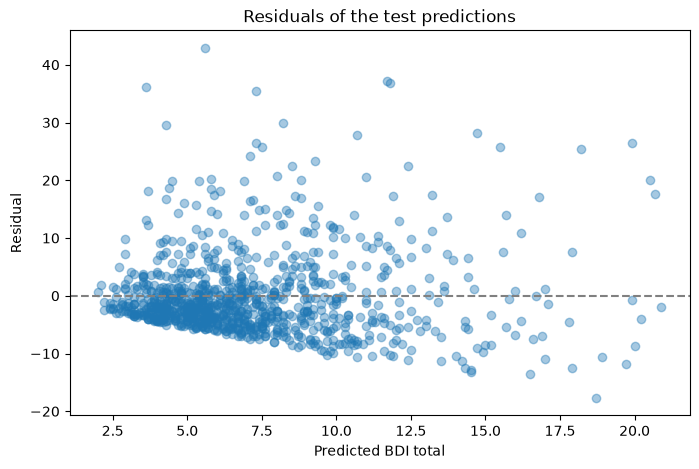

In [14]:
results["residual"] = (y_test.values - y_pred).round(1)
results.head(10)

plt.figure(figsize=(8, 5))
plt.scatter(results["predicted_bdi_total"], results["residual"], alpha=0.4)
plt.axhline(0, linestyle="--", color="grey")
plt.xlabel("Predicted BDI total")
plt.ylabel("Residual")
plt.title("Residuals of the test predictions")
plt.show()

## **Explanation**

- The residuals are not randomly scattered around zero, they trend downward as predicted BDI total increases: strongly positive residuals (actual > predicted) at low predicted values, strongly negative residuals (actual < predicted) at high predicted values.
- This is a regression-to-the-mean / compression pattern: predictions cluster narrowly (roughly 2.5–22) while actual BDI totals range much wider (the sample head showed actuals like 24 predicted as 6). The model is pulling everyone toward an average prediction instead of spreading out to match the real spread of scores.
- Combined with the multicollinearity in the step-4 coefficients (the screen-time index and its raw components fighting each other), this pattern is consistent with the model not having enough genuinely independent, predictive signal in the feature set to separate low- from high-symptom individuals confidently.

## **What this means for the presentation**
The honest story is: the pipeline and evaluation are done correctly, the model isn't overfitting, but screen time and sleep quality alone are weak predictors of BDI total, and the model systematically compresses its predictions toward the middle rather than tracking the true spread of scores. That's a defensible, presentable conclusion; not a bug to fix, but a finding about the limits of these two variables as predictors.